In [1]:
import pandas as pd
import numpy as np

In [56]:
df_before = pd.read_csv('/Users/emersonfrost/Desktop/MLfCC/mlcc-final-project/before_30_7')
df_after = pd.read_csv('/Users/emersonfrost/Desktop/MLfCC/mlcc-final-project/after_30')

In [57]:
df_before.shape[0] / 7

4357.0

In [58]:
df_after.shape

(17428, 21)

In [59]:
df_before.head(14)

,system:index,NIR,SWIR,blue,cloud_score,cyanobacteria_abundance,green,latitude,longitude,ndci,...,ndwi,red,red_edge,sample_date,satellite_date,.geo,tot_diff_days,mean_diff_days,median_diff_days,std_diff_days
0,9062_20160117T182712_20160117T183427_T11SMT,0.117157,0.197307,0.068217,0.072852,3824.5,0.086842,33.474200,-117.137998,0.302050,...,-0.246461,0.101563,0.159807,2016-01-21,2016-01-17,"{""type"":""MultiPoint"",""coordinates"":[]}",71.0,11.166667,10.0,5.269409
1,9062_20151231T183752_20151231T183755_T11SMT,0.118239,0.181915,0.073154,0.000228,3824.5,0.094558,33.474200,-117.137998,0.270032,...,-0.209679,0.108157,0.153717,2016-01-21,2015-12-31,"{""type"":""MultiPoint"",""coordinates"":[]}",71.0,11.166667,10.0,5.269409
2,9062_20151228T183312_20151228T183309_T11SMT,0.138406,0.206684,0.087906,0.072584,3824.5,0.108789,33.474200,-117.137998,0.275410,...,-0.193040,0.119495,0.181531,2016-01-21,2015-12-28,"{""type"":""MultiPoint"",""coordinates"":[]}",71.0,11.166667,10.0,5.269409
3,9062_20151218T182802_20151218T182756_T11SMT,0.126158,0.202519,0.072346,0.000702,3824.5,0.094635,33.474200,-117.137998,0.345760,...,-0.253196,0.106488,0.180982,2016-01-21,2015-12-18,"{""type"":""MultiPoint"",""coordinates"":[]}",71.0,11.166667,10.0,5.269409
4,9062_20151208T183312_20151208T183309_T11SMT,0.129843,0.200796,0.070884,0.038293,3824.5,0.094722,33.474200,-117.137998,0.361775,...,-0.242766,0.105682,0.189615,2016-01-21,2015-12-08,"{""type"":""MultiPoint"",""coordinates"":[]}",71.0,11.166667,10.0,5.269409
5,9062_20151121T184422_20151121T184425_T11SMT,0.128463,0.192753,0.074177,0.000007,3824.5,0.098254,33.474200,-117.137998,0.374142,...,-0.241988,0.107506,0.188575,2016-01-21,2015-11-21,"{""type"":""MultiPoint"",""coordinates"":[]}",71.0,11.166667,10.0,5.269409
6,9062_20151111T184002_20151111T183956_T11SMT,0.122889,0.180506,0.078283,0.012064,3824.5,0.103311,33.474200,-117.137998,0.404530,...,-0.200453,0.106544,0.196478,2016-01-21,2015-11-11,"{""type"":""MultiPoint"",""coordinates"":[]}",71.0,11.166667,10.0,5.269409
7,9063_20160117T182712_20160117T183427_T11SMT,0.098329,0.216473,0.031464,0.072852,5943.0,0.053812,33.477901,-117.141998,0.401405,...,-0.299300,0.069213,0.163292,2016-01-21,2016-01-17,"{""type"":""MultiPoint"",""coordinates"":[]}",71.0,11.166667,10.0,5.269409
8,9063_20151231T183752_20151231T183755_T11SMT,0.083996,0.193533,0.023260,0.000228,5943.0,0.039784,33.477901,-117.141998,0.406114,...,-0.366930,0.057544,0.134886,2016-01-21,2015-12-31,"{""type"":""MultiPoint"",""coordinates"":[]}",71.0,11.166667,10.0,5.269409
9,9063_20151228T183312_20151228T183309_T11SMT,0.098287,0.218209,0.035785,0.072584,5943.0,0.053873,33.477901,-117.141998,0.389605,...,-0.298316,0.069005,0.156130,2016-01-21,2015-12-28,"{""type"":""MultiPoint"",""coordinates"":[]}",71.0,11.166667,10.0,5.269409


1. get weather data for satellite date for each one
2. run an LSTM model to predict satellite band data (one week, two week, one month, two month)
3. use clima x model (or something similar) to predict weather or climate (one week, two week, one month, two month)
4. take nutrient data for most recent call there to the "sample_date" - use for week 1 and 2
5. Then use these three categories of variables to run our best regressor

## LSTM for Satellite Band Data

In [60]:
#code here
#L (sequence length) = 7
#N (batch size) = ? 
#D = 1 (one directional)
#Hin (input_size) = 4357

In [61]:
import torch

In [62]:
temp = torch.randn(5,3,10)
#10 time steps, 3 columns, 5 variables

In [63]:
print(temp)

tensor([[[-0.9695, -1.3178, -1.1569,  0.0266,  1.1471, -1.8900,  2.6625,
          -0.6969, -0.2034,  0.1130],
         [ 1.3249, -0.4141,  1.4578,  0.1544,  1.5284, -1.3158, -1.3131,
          -1.3104,  0.3955, -0.0660],
         [-0.6447, -2.6080, -2.2765,  0.4055, -0.5243, -0.5319,  0.1669,
           0.6791, -1.6009, -0.2491]],

        [[-0.3526,  1.3657, -0.3011,  0.4959, -0.4344, -1.5504,  0.4222,
          -0.5655, -0.5070,  0.6067],
         [-1.9964,  1.2983, -0.0911,  1.0235, -3.0452,  0.2734, -0.9722,
           0.6577, -0.3240, -0.3072],
         [-1.0352,  0.4764,  1.3070,  0.1612,  1.1880,  0.4789, -1.1167,
           0.9587,  1.6326,  0.8992]],

        [[ 0.3312,  1.2931, -0.1276,  0.3775, -0.2040,  0.7252, -1.0881,
          -0.6826, -0.8308, -0.6578],
         [ 0.6659, -0.3826, -1.4106, -1.4555, -1.5079,  1.4717, -1.0300,
           0.2903, -1.2233, -1.0957],
         [ 0.0702,  1.2748,  0.1638,  0.2517,  1.5311,  1.4313, -0.6668,
           0.6342, -0.0305,  0.6899

In [64]:
#need to transform data into this format
df_before.columns

Index(['system:index', 'NIR', 'SWIR', 'blue', 'cloud_score',
       'cyanobacteria_abundance', 'green', 'latitude', 'longitude', 'ndci',
       'ndti', 'ndvi', 'ndwi', 'red', 'red_edge', 'sample_date',
       'satellite_date', '.geo', 'tot_diff_days', 'mean_diff_days',
       'median_diff_days', 'std_diff_days'],
      dtype='object')

In [65]:
df_before = df_before.sort_values(by = ['latitude', 'longitude', 'sample_date', 'cyanobacteria_abundance', 'satellite_date'])

In [200]:
#placing into the correct format
df_before = df_before.sort_values(by = ['latitude', 'longitude', 'sample_date', 'cyanobacteria_abundance', 'satellite_date'])
feature_cols2 = ['ndvi', 'ndwi', 'ndci']
feature_cols = ['NIR', 'SWIR', 'blue', 'green', 'ndci', 'ndti', 'ndvi', 'ndwi', 'red', 'red_edge', 'cloud_score', 'mean_diff_days', 'std_diff_days']
xdata = []
ydata = []

groups = ['latitude', 'longitude', 'sample_date', 'cyanobacteria_abundance'] 

for _, group in df_before.groupby(groups):
    group = group.sort_values('satellite_date')

    #ensure sequence is of length 7
    if len(group) == 7:
        seq = group[feature_cols].values

        #input features
        xdata.append(seq)

        #target feature
        ydata.append(group['cyanobacteria_abundance'].iloc[0])

xdata = np.array(xdata)
ydata = np.array(ydata)
#take log of cyanobacteria abundance
ydata = np.log1p(ydata)
print(xdata.shape)
print(ydata.shape)

(4320, 7, 13)
(4320,)


In [201]:
#normalize features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
n_samples, seq_len, n_features = xdata.shape
x2d = xdata.reshape(-1, n_features)
x_scaled_2d = scaler.fit_transform(x2d)
x_scaled = x_scaled_2d.reshape(n_samples, seq_len, n_features)

print(x_scaled.shape)

(4320, 7, 13)


In [202]:
#make into tensors to load
x_tensor = torch.tensor(x_scaled, dtype = torch.float32)
y_tensor = torch.tensor(ydata, dtype = torch.float32)

In [203]:
from sklearn.model_selection import train_test_split

#test split
xtrain, xtemp, ytrain, ytemp = train_test_split(xdata, ydata, test_size = 0.2, random_state = 999)
xval, xtest, yval, ytest = train_test_split(xtemp, ytemp, test_size = 0.5, random_state = 999)

In [204]:
from torch.utils.data import Dataset

#creating time series class to load into dataloader
class TimeSeries(Dataset):
    def __init__(self, xdata, ydata):
        self.xdata = torch.tensor(xdata, dtype = torch.float32)
        self.ydata = torch.tensor(ydata, dtype = torch.float32)

    def __len__(self):
        return len(self.xdata)

    def __getitem__(self, idx):
        return self.xdata[idx], self.ydata[idx]

In [205]:
from torch.utils.data import DataLoader

train_df = TimeSeries(xtrain, ytrain)
val_df = TimeSeries(xval, yval)

train_loader = DataLoader(train_df, batch_size = 32, shuffle = True)
val_loader = DataLoader(val_df, batch_size = 32, shuffle = False)

In [206]:
#building LSTM class
import torch.nn as nn

#want to predict one value (cyanobacteria abundance)
class LSTMmodel(nn.Module):
    def __init__(self, input_size, hidden_size = 64, num_layers = 1):
        super().__init__()

        #initialize lstm model
        self.lstm = nn.LSTM(
            input_size = input_size,
            hidden_size = hidden_size,
            num_layers = num_layers,
            batch_first = True 
        )
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)

        last_out = lstm_out[:, -1, :]

        out = self.fc(last_out)
        return out.squeeze()

In [196]:
#initializing / prepping for LSTM
device = torch.device("cude" if torch.cuda.is_available() else "cpu")

#model --> mess around with hyperparameters later
model = LSTMmodel(input_size = xdata.shape[2], hidden_size = 16).to(device)

#try different loss functions
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr = 0.1) #also try different learning rates

In [197]:
#training loop & validation
num_epochs = 30
for epoch in range(num_epochs):

    #implement training
    model.train()
    train_loss = 0

    for xbatch, ybatch in train_loader:
        xbatch = xbatch.to(device)
        ybatch = ybatch.to(device)
        optimizer.zero_grad()

        preds = model(xbatch)
        loss = criterion(preds, ybatch)

        #gradient descent
        loss.backward()
        optimizer.step() 

        train_loss += loss.item()

    train_loss /= len(train_loader)

    #validation
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for xbatch, ybatch in val_loader:
            xbatch = xbatch.to(device)
            ybatch = ybatch.to(device)

            preds = model(xbatch)
            loss = criterion(preds, ybatch)

            val_loss += loss.item()

        val_loss /= len(val_loader)

        print(f"Epoch {epoch+1}: Train Loss = {train_loss:.4f}, Validation Loss = {val_loss:.4f}, RMSE = {val_loss ** 0.5:.4f}")
        

Epoch 1: Train Loss = 8.8695, Validation Loss = 8.4954, RMSE = 2.9147
Epoch 2: Train Loss = 7.7832, Validation Loss = 8.4593, RMSE = 2.9085
Epoch 3: Train Loss = 7.8420, Validation Loss = 8.4433, RMSE = 2.9057
Epoch 4: Train Loss = 8.0382, Validation Loss = 8.5033, RMSE = 2.9160
Epoch 5: Train Loss = 7.8179, Validation Loss = 8.4426, RMSE = 2.9056
Epoch 6: Train Loss = 7.8971, Validation Loss = 8.8696, RMSE = 2.9782
Epoch 7: Train Loss = 7.9453, Validation Loss = 8.4788, RMSE = 2.9118
Epoch 8: Train Loss = 7.8335, Validation Loss = 8.4776, RMSE = 2.9116
Epoch 9: Train Loss = 7.7839, Validation Loss = 8.4357, RMSE = 2.9044
Epoch 10: Train Loss = 8.0052, Validation Loss = 8.4365, RMSE = 2.9046
Epoch 11: Train Loss = 7.7030, Validation Loss = 8.5541, RMSE = 2.9247
Epoch 12: Train Loss = 7.8883, Validation Loss = 8.5058, RMSE = 2.9165
Epoch 13: Train Loss = 7.8189, Validation Loss = 8.5261, RMSE = 2.9199
Epoch 14: Train Loss = 7.8472, Validation Loss = 8.5444, RMSE = 2.9231
Epoch 15: Train

In [198]:
print(preds[:20])
print(ydata[:20])

tensor([7.5639, 7.5640, 7.5640, 5.2327, 7.5640, 5.4022, 3.5623, 5.2325, 5.2340,
        5.2327, 3.4835, 5.2328, 5.2332, 7.5640, 5.2361, 5.2327])
[5.02218828 6.43517069 5.78322824 7.25779522 5.84324838 4.17855701
 5.759928   6.21095342 6.8869062  6.2877779  6.38585857 0.07219369
 4.44738428 5.1330965  2.58929631 2.27928837 1.73462745 2.94609084
 7.50734699 5.12656529]


In [158]:
#no longer predicting the mean every time --> still noisy not predictive features in many cases
#model with just ndvi ... performed very similarly
#converges very fast + doesn't improve a ton

#creating a function for hyperparameter testing
def try_new_model(input_size, hidden_size, num_layers, learning_rate, loss_type): 
    print()
    #print out specifics of this model
    print(f"hidden size = {hidden_size}, lr = {learning_rate}, loss type = {loss_type}")
    #initializing / prepping for LSTM
    device = torch.device("cude" if torch.cuda.is_available() else "cpu")

    #model --> mess around with hyperparameters later
    model = LSTMmodel(input_size = input_size, hidden_size = hidden_size, num_layers = num_layers).to(device)
    
    #MSE loss function
    if loss_type == "mse":    
        criterion = nn.MSELoss()
    elif loss_type == "mae":
        criterion = nn.L1Loss()
    elif loss_type == "huber":
        criterion = nn.SmoothL1Loss()
    optimizer = torch.optim.Adam(model.parameters(), lr = learning_rate)

    #training loop & validation
    num_epochs = 30
    for epoch in range(num_epochs):

        #implement training
        model.train()
        train_loss = 0

        for xbatch, ybatch in train_loader:
            xbatch = xbatch.to(device)
            ybatch = ybatch.to(device)
            optimizer.zero_grad()

            preds = model(xbatch)
            loss = criterion(preds, ybatch)

            #gradient descent
            loss.backward()
            optimizer.step() 

            train_loss += loss.item()

        train_loss /= len(train_loader)

        #validation
        model.eval()
        val_loss = 0
        rmse_sum = 0
        n_samples = 0
        #use to calculate r2
        y_all = []
        pred_all = []
        with torch.no_grad():
            for xbatch, ybatch in val_loader:
                xbatch = xbatch.to(device)
                ybatch = ybatch.to(device)

                preds = model(xbatch)
                loss = criterion(preds, ybatch)

                val_loss += loss.item()
                rmse_sum += ((preds - ybatch) ** 2).sum().item()
                n_samples += ybatch.numel()

            val_loss /= len(val_loader)
            rmse = (rmse_sum / n_samples) ** 0.5

        #print final training + validation loss
        if epoch == 29: 
            print(f"Epoch {epoch+1}: Train Loss = {train_loss:.4f}, Validation Loss = {val_loss:.4f}, RMSE = {rmse:.4f}")

    #print first few predictions + actual values
    print(preds[:5])
    print(ydata[:5])


#define a function run a specific model & return preds vs. ydata
def run_model(input_size, hidden_size, num_layers, learning_rate, loss_type):
    #initializing / prepping for LSTM
    device = torch.device("cude" if torch.cuda.is_available() else "cpu")

    #model
    model = LSTMmodel(input_size = input_size, hidden_size = hidden_size, num_layers = num_layers).to(device)
    
    #MSE loss function
    if loss_type == "mse":    
        criterion = nn.MSELoss()
    elif loss_type == "mae":
        criterion = nn.L1Loss()
    elif loss_type == "huber":
        criterion = nn.SmoothL1Loss()
    optimizer = torch.optim.Adam(model.parameters(), lr = learning_rate)
    
    #training loop & validation
    num_epochs = 30
    for epoch in range(num_epochs):

        #implement training
        model.train()
        train_loss = 0

        for xbatch, ybatch in train_loader:
            xbatch = xbatch.to(device)
            ybatch = ybatch.to(device)
            optimizer.zero_grad()

            preds = model(xbatch)
            loss = criterion(preds, ybatch)

            #gradient descent
            loss.backward()
            optimizer.step() 

            train_loss += loss.item()

        train_loss /= len(train_loader)

        #validation
        model.eval()
        val_loss = 0
        rmse_sum = 0
        n_samples = 0
        #get predictions and ys
        y_all = []
        pred_all = []
        with torch.no_grad():
            for xbatch, ybatch in val_loader:
                xbatch = xbatch.to(device)
                ybatch = ybatch.to(device)

                preds = model(xbatch)
                loss = criterion(preds, ybatch)

                val_loss += loss.item()
                rmse_sum += ((preds - ybatch) ** 2).sum().item()
                n_samples += ybatch.numel()

                y_all.append(ybatch.cpu())
                pred_all.append(preds.cpu())
            
        val_loss /= len(val_loader)
        rmse = (rmse_sum / n_samples) ** 0.5
         
        #predictions & ys 
        y_all = torch.cat(y_all)
        pred_all = torch.cat(pred_all)

    return pred_all, y_all, model, rmse

In [142]:
#train a few different models & compare best results (only 30% cloudiness)

#input_size (13)
#hidden_size = 32, 16, 68
#num layers = 1
#lr = 1, 0.1, 0.01
#loss_type = mse, huber, mae

#all MSE models
try_new_model(xdata.shape[2], 32, 1, 0.1, "mse")
try_new_model(xdata.shape[2], 32, 1, 0.01, "mse")
try_new_model(xdata.shape[2], 32, 1, 0.001, "mse")
try_new_model(xdata.shape[2], 16, 1, .1, "mse")
try_new_model(xdata.shape[2], 8, 1, .1, "mse")
try_new_model(xdata.shape[2], 16, 1, 0.01, "mse")
try_new_model(xdata.shape[2], 16, 1, 0.001, "mse")
try_new_model(xdata.shape[2], 8, 1, 0.01, "mse")
try_new_model(xdata.shape[2], 8, 1, 0.001, "mse")

#all MAE models
try_new_model(xdata.shape[2], 32, 1, .1, "mae")
try_new_model(xdata.shape[2], 32, 1, 0.01, "mae")
try_new_model(xdata.shape[2], 32, 1, 0.001, "mae")
try_new_model(xdata.shape[2], 16, 1, .1, "mae")
try_new_model(xdata.shape[2], 16, 1, 0.01, "mae")
try_new_model(xdata.shape[2], 16, 1, 0.001, "mae")
try_new_model(xdata.shape[2], 8, 1, .1, "mae")
try_new_model(xdata.shape[2], 8, 1, 0.01, "mae")
try_new_model(xdata.shape[2], 8, 1, 0.001, "mae")

#all huber models
try_new_model(xdata.shape[2], 32, 1, .1, "huber")
try_new_model(xdata.shape[2], 32, 1, 0.01, "huber")
try_new_model(xdata.shape[2], 32, 1, 0.001, "huber")
try_new_model(xdata.shape[2], 16, 1, .1, "huber")
try_new_model(xdata.shape[2], 16, 1, 0.01, "huber")
try_new_model(xdata.shape[2], 16, 1, 0.001, "huber")
try_new_model(xdata.shape[2], 8, 1, .1, "huber")
try_new_model(xdata.shape[2], 8, 1, 0.01, "huber")
try_new_model(xdata.shape[2], 8, 1, 0.001, "huber")


hidden size = 32, lr = 0.1, loss type = mse
Epoch 30: Train Loss = 8.1745, Validation Loss = 8.7176, RMSE = 2.9604
R-squared = -0.0011
tensor([5.5546, 5.5546, 5.5546, 5.5546, 5.5546])
[5.02218828 6.43517069 5.78322824 7.25779522 5.84324838]

hidden size = 32, lr = 0.01, loss type = mse
Epoch 30: Train Loss = 4.6277, Validation Loss = 5.5862, RMSE = 2.3845
R-squared = 0.6112
tensor([7.8686, 7.3955, 7.7293, 3.5776, 7.8751])
[5.02218828 6.43517069 5.78322824 7.25779522 5.84324838]

hidden size = 32, lr = 0.001, loss type = mse
Epoch 30: Train Loss = 4.8410, Validation Loss = 5.5818, RMSE = 2.3840
R-squared = 0.6187
tensor([8.1816, 7.9086, 8.0240, 3.8422, 8.0729])
[5.02218828 6.43517069 5.78322824 7.25779522 5.84324838]

hidden size = 16, lr = 0.1, loss type = mse
Epoch 30: Train Loss = 5.6694, Validation Loss = 6.9931, RMSE = 2.6686
R-squared = 0.5262
tensor([6.9239, 6.9239, 6.9231, 3.9873, 6.9237])
[5.02218828 6.43517069 5.78322824 7.25779522 5.84324838]

hidden size = 8, lr = 0.1, loss

2.378674933959914
tensor([5.0100, 7.3810, 4.8460, 7.4594, 6.2925])
tensor([5.2606, 8.9400, 8.9029, 7.8024, 8.5023])


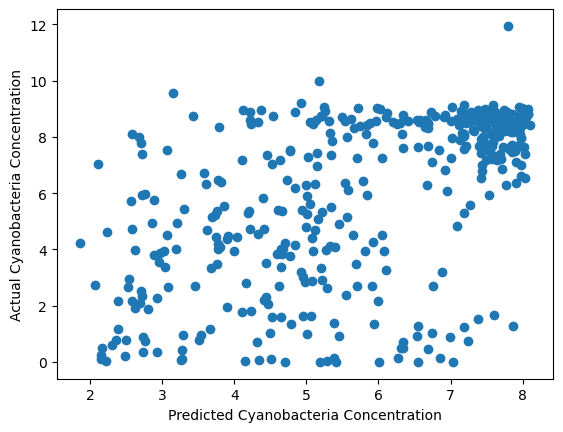

0.33151066303253174


In [159]:
#choose best 3 RMSE and best 3 r2
#best RMSE: 
#1 (2.369) hs = 32, lr = 0.01, loss = mse 
#2 (2.378) hs = 32, lr = 0.001, loss = mse
#3 (2.382) hs = 16, lr = 0.001, loss = mse
#best r2
#1 (0.749) hs = 8, lr = 0.01, loss = mae
#2 (0.7170) hs = 16, lr = 0.1, loss = huber
#3 (0.703) hs = 8, lr = 0.001, loss = huber
#VERY INCONSISTENT across runs --> choose best by rmse
from matplotlib import pyplot as plt
from sklearn.metrics import r2_score


#best one plot predicted vs. actual --> calculate r2 from thse + plot
p1, y1, m1, rmse1 = run_model(xdata.shape[2], 32, 1, 0.01, "mse")
print(rmse1)
print(p1[:5])
print(y1[:5])
p1 = p1.numpy()
y1 = y1.numpy()
r2 = r2_score(y1, p1)

plt.scatter(p1, y1)
plt.xlabel("Predicted Cyanobacteria Concentration")
plt.ylabel("Actual Cyanobacteria Concentration")
plt.show()
print(r2)




In [216]:
from sklearn.model_selection import KFold
from torch.utils.data import TensorDataset, DataLoader
import numpy as np

def run_kfold(X, y, hidden_size, num_layers, lr, loss_type, k=5):

    #print out specifics of this model
    print(f"hidden size = {hidden_size}, lr = {lr}, loss type = {loss_type}")
    
    kf = KFold(
        n_splits=k,
        shuffle=True,
        random_state=42
    )

    rmse_scores=[]
    r2_scores=[]

    for fold,(train_idx,val_idx) in enumerate(kf.split(X)):

        #loading data into dataloader
        X_train = X[train_idx]
        y_train = y[train_idx]
        X_val = X[val_idx]
        y_val = y[val_idx]
        train_ds = TensorDataset(
            torch.tensor(X_train,dtype=torch.float32),
            torch.tensor(y_train,dtype=torch.float32)
        )
        val_ds = TensorDataset(
            torch.tensor(X_val,dtype=torch.float32),
            torch.tensor(y_val,dtype=torch.float32)
        )
        train_loader = DataLoader(
            train_ds,
            batch_size=32,
            shuffle=True
        )
        val_loader = DataLoader(
            val_ds,
            batch_size=32,
            shuffle=False
        )
        preds,true,model,rmse,r2 = run_model(
            train_loader,
            val_loader,
            X.shape[2],
            hidden_size,
            num_layers,
            lr,
            loss_type
        )

        #updating scores
        rmse_scores.append(rmse)
        r2_scores.append(r2)

    print(f"RMSE: {np.mean(rmse_scores):.3f} ± {np.std(rmse_scores):.3f}")
    print(f"R2: {np.mean(r2_scores):.3f} ± {np.std(r2_scores):.3f}")
    print()

    return rmse_scores,r2_scores

#tweaked run_model code to work with wrapper
def run_model(train_loader, val_loader, input_size, hidden_size, num_layers, learning_rate, loss_type):

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    #change this to GRU or LSTM depending on what I want
    model = GRUmodel(
        input_size=input_size,
        hidden_size=hidden_size,
        num_layers=num_layers
    ).to(device)


    # loss function
    if loss_type == "mse":
        criterion = nn.MSELoss()

    elif loss_type == "mae":
        criterion = nn.L1Loss()

    elif loss_type == "huber":
        criterion = nn.SmoothL1Loss()

    optimizer = torch.optim.Adam(model.parameters(),lr=learning_rate)

    #iterations
    num_epochs = 30
    for epoch in range(num_epochs):
        #training
        model.train()
        train_loss=0
        for xbatch,ybatch in train_loader:
            xbatch=xbatch.to(device)
            ybatch=ybatch.to(device).view(-1,1)
            optimizer.zero_grad()
            preds=model(xbatch)
            loss=criterion(preds,ybatch)
            loss.backward()
            optimizer.step()
            train_loss+=loss.item()
        
        train_loss/=len(train_loader)

        #validation set
        model.eval()
        val_loss=0
        y_all=[]
        pred_all=[]
        with torch.no_grad():
            for xbatch,ybatch in val_loader:
                xbatch=xbatch.to(device)
                ybatch=ybatch.to(device).view(-1,1)
                preds=model(xbatch)
                loss=criterion(preds,ybatch)

                val_loss+=loss.item()

                y_all.append(ybatch.cpu())

                pred_all.append(preds.cpu())
        val_loss/=len(val_loader)

    #metrics
    y_all=torch.cat(y_all)
    pred_all=torch.cat(pred_all)
    pred_np=pred_all.numpy()
    y_np=y_all.numpy()

    #rmse
    rmse = np.sqrt(np.mean((pred_np-y_np)**2))

    #r2
    r2 = r2_score(y_np,pred_np)
    return (pred_all, y_all, model, rmse, r2)

In [186]:
print(x_scaled.shape)
print(ydata.shape)

(4320, 7, 13)
(4320,)


hidden size = 32, lr = 0.01, loss type = mse
RMSE: 2.096 ± 0.054
R2: 0.435 ± 0.026

hidden size = 16, lr = 0.01, loss type = mse
RMSE: 2.064 ± 0.071
R2: 0.452 ± 0.036

hidden size = 8, lr = 0.01, loss type = mse
RMSE: 2.101 ± 0.055
R2: 0.432 ± 0.027

hidden size = 8, lr = 0.01, loss type = mae
RMSE: 2.167 ± 0.062
R2: 0.396 ± 0.035

hidden size = 16, lr = 0.01, loss type = huber
RMSE: 2.135 ± 0.079
R2: 0.413 ± 0.043



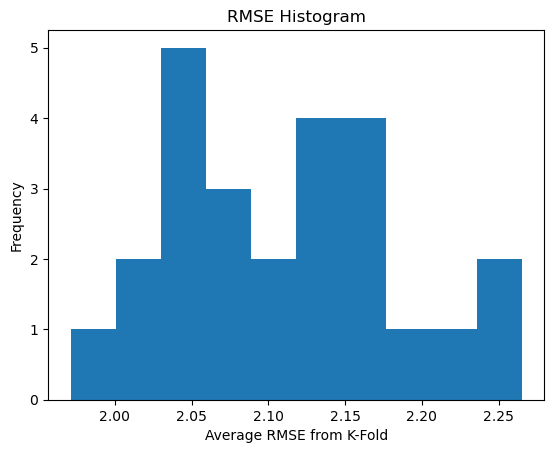

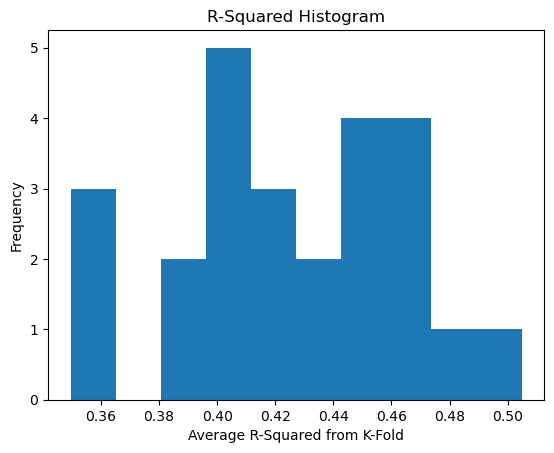

In [207]:
#running k-fold on different model varieties
#model 1
rmse_1, r2_1 = run_kfold(x_scaled, ydata, 
                                   hidden_size = 32, 
                                   num_layers = 1,
                                   lr = 0.01,
                                   loss_type = "mse",
                                   k = 5)

#model 2
rmse_2, r2_2 = run_kfold(x_scaled, ydata, hidden_size = 16, num_layers = 1, lr = 0.01, loss_type = 'mse', k = 5)
#model 3
rmse_3, r2_3 = run_kfold(x_scaled, ydata, 8, 1, 0.01, 'mse', k = 5)
#model 4
rmse_4, r2_4 = run_kfold(x_scaled, ydata, 8, 1, 0.01, 'mae', k = 5)
#model 5
rmse_5, r2_5 = run_kfold(x_scaled, ydata, 16, 1, 0.01, 'huber', k = 5)

#plotting a histogram of rmse and r2 values
all_rmses = rmse_1 + rmse_2 + rmse_3 + rmse_4 + rmse_5
all_r2s = r2_1 + r2_2 + r2_3 + r2_4 + r2_5
#RMSE
plt.hist(all_rmses)
plt.title("RMSE Histogram")
plt.xlabel("Average RMSE from K-Fold")
plt.ylabel("Frequency")
plt.show()

#R2s
plt.hist(all_r2s)
plt.title("R-Squared Histogram")
plt.xlabel("Average R-Squared from K-Fold")
plt.ylabel("Frequency")
plt.show()

In [208]:
#running k-fold LSTM method the data from 50% and 70% data --> all the data preperation
df2 = pd.read_csv('/Users/emersonfrost/Desktop/MLfCC/mlcc-final-project/before_50_8')

#placing into the correct format
df2 = df2.sort_values(by = ['latitude', 'longitude', 'sample_date', 'cyanobacteria_abundance', 'satellite_date'])
feature_cols = ['NIR', 'SWIR', 'blue', 'green', 'ndci', 'ndti', 'ndvi', 'ndwi', 'red', 'red_edge',
               'cloud_score', 'mean_diff_days', 'std_diff_days']
xdata2 = []
ydata2 = []

groups = ['latitude', 'longitude', 'sample_date', 'cyanobacteria_abundance'] 

for _, group in df2.groupby(groups):
    group = group.sort_values('satellite_date')

    #ensure sequence is of length 8
    if len(group) == 8:
        seq = group[feature_cols].values

        #input features
        xdata2.append(seq)

        #target feature
        ydata2.append(group['cyanobacteria_abundance'].iloc[0])

xdata2 = np.array(xdata2)
ydata2 = np.array(ydata2)
#take log of cyanobacteria abundance
ydata2 = np.log1p(ydata2)
#scale
scaler = StandardScaler()
n_samples, seq_len, n_features = xdata2.shape
x2d = xdata2.reshape(-1, n_features)
x_scaled_2d = scaler.fit_transform(x2d)
x_scaled2 = x_scaled_2d.reshape(n_samples, seq_len, n_features)
print("Shape of Data for 50%")
print(x_scaled2.shape)

#now for 70% data
df3 = pd.read_csv('/Users/emersonfrost/Desktop/MLfCC/mlcc-final-project/before_70_9')
#into correct format
df3 = df3.sort_values(by = ['latitude', 'longitude', 'sample_date', 'cyanobacteria_abundance', 'satellite_date'])
feature_cols = ['NIR', 'SWIR', 'blue', 'green', 'ndci', 'ndti', 'ndvi', 'ndwi', 'red', 'red_edge','cloud_score', 'mean_diff_days', 'std_diff_days']
xdata3 = []
ydata3 = []

groups = ['latitude', 'longitude', 'sample_date', 'cyanobacteria_abundance'] 

for _, group in df3.groupby(groups):
    group = group.sort_values('satellite_date')

    #ensure sequence is of length 9
    if len(group) == 9:
        seq = group[feature_cols].values

        #input features
        xdata3.append(seq)

        #target feature
        ydata3.append(group['cyanobacteria_abundance'].iloc[0])

xdata3 = np.array(xdata3)
ydata3 = np.array(ydata3)
#take log of cyanobacteria abundance
ydata3 = np.log1p(ydata3)
#scale
scaler = StandardScaler()
n_samples, seq_len, n_features = xdata3.shape
x2d = xdata3.reshape(-1, n_features)
x_scaled_2d = scaler.fit_transform(x2d)
x_scaled3 = x_scaled_2d.reshape(n_samples, seq_len, n_features)
print("Shape of Data for 70%")
print(x_scaled3.shape)

Shape of Data for 50%
(5076, 8, 13)
Shape of Data for 70%
(5319, 9, 13)


hidden size = 32, lr = 0.01, loss type = mse
RMSE: 2.120 ± 0.079
R2: 0.458 ± 0.043

hidden size = 16, lr = 0.01, loss type = mse
RMSE: 2.069 ± 0.062
R2: 0.484 ± 0.032

hidden size = 8, lr = 0.01, loss type = mse
RMSE: 2.117 ± 0.047
R2: 0.460 ± 0.027

hidden size = 8, lr = 0.01, loss type = mae
RMSE: 2.200 ± 0.034
R2: 0.417 ± 0.018

hidden size = 16, lr = 0.01, loss type = huber
RMSE: 2.158 ± 0.072
R2: 0.439 ± 0.037



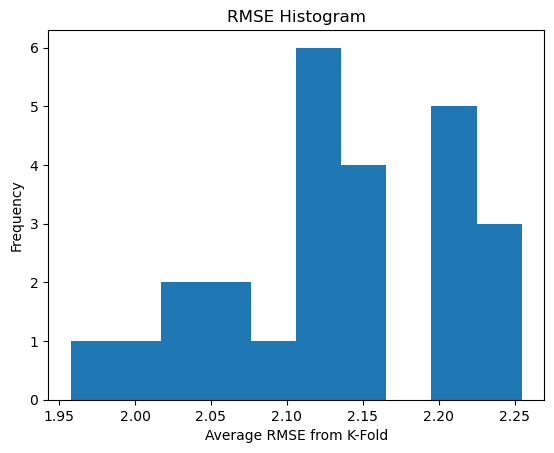

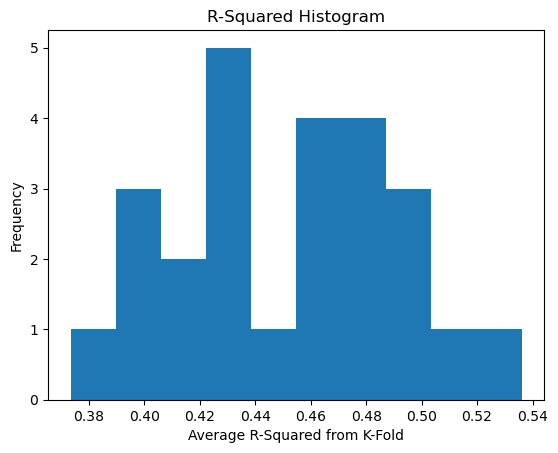

In [209]:
#50% cloudiness cut off models
#model 1
rmse_1, r2_1 = run_kfold(x_scaled2, ydata2, 
                                   hidden_size = 32, 
                                   num_layers = 1,
                                   lr = 0.01,
                                   loss_type = "mse",
                                   k = 5)

#model 2
rmse_2, r2_2 = run_kfold(x_scaled2, ydata2, hidden_size = 16, num_layers = 1, lr = 0.01, loss_type = 'mse', k = 5)
#model 3
rmse_3, r2_3 = run_kfold(x_scaled2, ydata2, 8, 1, 0.01, 'mse', k = 5)
#model 4
rmse_4, r2_4 = run_kfold(x_scaled2, ydata2, 8, 1, 0.01, 'mae', k = 5)
#model 5
rmse_5, r2_5 = run_kfold(x_scaled2, ydata2, 16, 1, 0.01, 'huber', k = 5)

#plotting a histogram of rmse and r2 values
all_rmses = rmse_1 + rmse_2 + rmse_3 + rmse_4 + rmse_5
all_r2s = r2_1 + r2_2 + r2_3 + r2_4 + r2_5
#RMSE
plt.hist(all_rmses)
plt.title("RMSE Histogram")
plt.xlabel("Average RMSE from K-Fold")
plt.ylabel("Frequency")
plt.show()

#R2s
plt.hist(all_r2s)
plt.title("R-Squared Histogram")
plt.xlabel("Average R-Squared from K-Fold")
plt.ylabel("Frequency")
plt.show()

hidden size = 32, lr = 0.01, loss type = mse
RMSE: 2.092 ± 0.036
R2: 0.482 ± 0.012

hidden size = 16, lr = 0.01, loss type = mse
RMSE: 2.052 ± 0.039
R2: 0.501 ± 0.019

hidden size = 8, lr = 0.01, loss type = mse
RMSE: 2.092 ± 0.052
R2: 0.482 ± 0.024

hidden size = 8, lr = 0.01, loss type = mae
RMSE: 2.226 ± 0.080
R2: 0.412 ± 0.046

hidden size = 16, lr = 0.01, loss type = huber
RMSE: 2.152 ± 0.083
R2: 0.452 ± 0.032



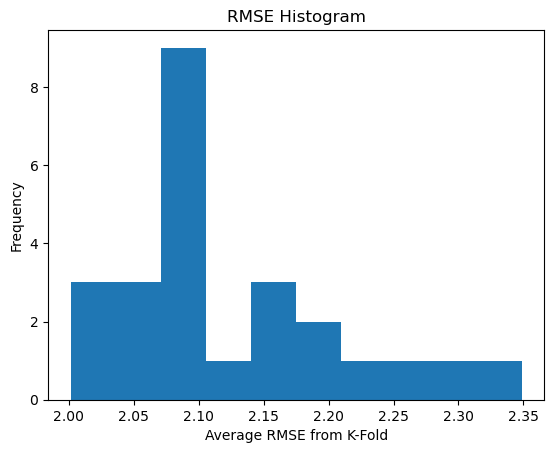

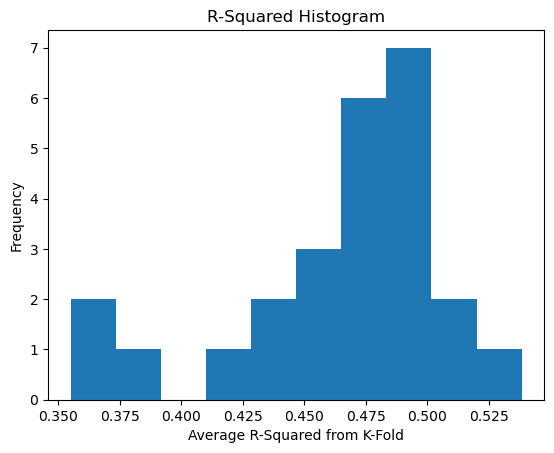

In [210]:
#70% cloudiness cutoff models
#model 1
rmse_1, r2_1 = run_kfold(x_scaled3, ydata3, 
                                   hidden_size = 32, 
                                   num_layers = 1,
                                   lr = 0.01,
                                   loss_type = "mse",
                                   k = 5)

#model 2
rmse_2, r2_2 = run_kfold(x_scaled3, ydata3, hidden_size = 16, num_layers = 1, lr = 0.01, loss_type = 'mse', k = 5)
#model 3
rmse_3, r2_3 = run_kfold(x_scaled3, ydata3, 8, 1, 0.01, 'mse', k = 5)
#model 4
rmse_4, r2_4 = run_kfold(x_scaled3, ydata3, 8, 1, 0.01, 'mae', k = 5)
#model 5
rmse_5, r2_5 = run_kfold(x_scaled3, ydata3, 16, 1, 0.01, 'huber', k = 5)

#plotting a histogram of rmse and r2 values
all_rmses = rmse_1 + rmse_2 + rmse_3 + rmse_4 + rmse_5
all_r2s = r2_1 + r2_2 + r2_3 + r2_4 + r2_5
#RMSE
plt.hist(all_rmses)
plt.title("RMSE Histogram")
plt.xlabel("Average RMSE from K-Fold")
plt.ylabel("Frequency")
plt.show()

#R2s
plt.hist(all_r2s)
plt.title("R-Squared Histogram")
plt.xlabel("Average R-Squared from K-Fold")
plt.ylabel("Frequency")
plt.show()

In [214]:
#GRU Model --> often better w/ smaller sets
class GRUmodel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers):
        super().__init__()

        self.gru = nn.GRU(input_size, hidden_size, num_layers, batch_first = True)
        self.fc = nn.Linear(hidden_size, 1)
    def forward(self, x):
        out, h = self.gru(x)
        out = self.fc(out[:,-1,:])
        return out
        

hidden size = 32, lr = 0.01, loss type = mse
RMSE: 2.098 ± 0.054
R2: 0.434 ± 0.031

hidden size = 16, lr = 0.01, loss type = mse
RMSE: 2.129 ± 0.068
R2: 0.417 ± 0.039

hidden size = 8, lr = 0.01, loss type = mse
RMSE: 2.092 ± 0.085
R2: 0.437 ± 0.042

hidden size = 8, lr = 0.01, loss type = mae
RMSE: 2.176 ± 0.068
R2: 0.391 ± 0.037

hidden size = 16, lr = 0.01, loss type = huber
RMSE: 2.190 ± 0.064
R2: 0.383 ± 0.038



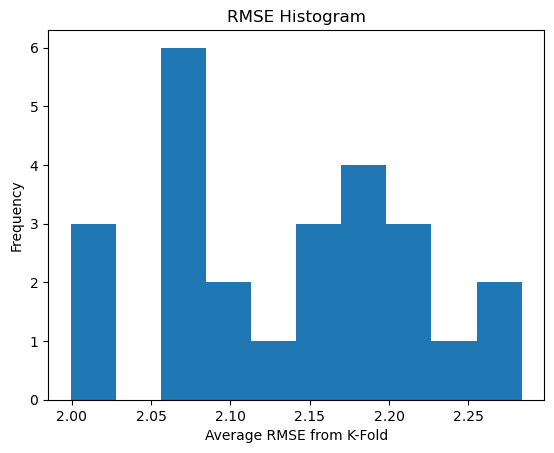

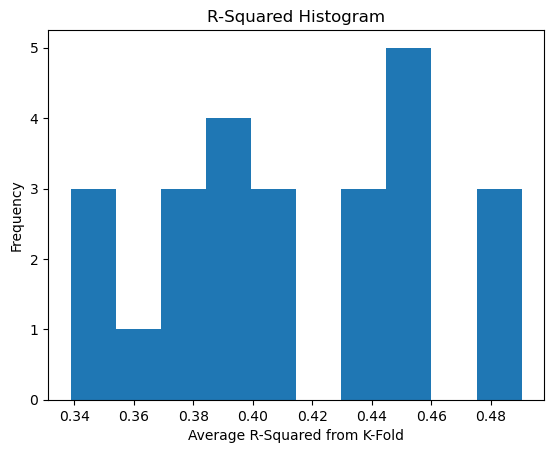

In [217]:
#run on 30% threshold
#model 1
rmse_1, r2_1 = run_kfold(x_scaled, ydata, 
                                   hidden_size = 32, 
                                   num_layers = 1,
                                   lr = 0.01,
                                   loss_type = "mse",
                                   k = 5)

#model 2
rmse_2, r2_2 = run_kfold(x_scaled, ydata, hidden_size = 16, num_layers = 1, lr = 0.01, loss_type = 'mse', k = 5)
#model 3
rmse_3, r2_3 = run_kfold(x_scaled, ydata, 8, 1, 0.01, 'mse', k = 5)
#model 4
rmse_4, r2_4 = run_kfold(x_scaled, ydata, 8, 1, 0.01, 'mae', k = 5)
#model 5
rmse_5, r2_5 = run_kfold(x_scaled, ydata, 16, 1, 0.01, 'huber', k = 5)

#plotting a histogram of rmse and r2 values
all_rmses = rmse_1 + rmse_2 + rmse_3 + rmse_4 + rmse_5
all_r2s = r2_1 + r2_2 + r2_3 + r2_4 + r2_5
#RMSE
plt.hist(all_rmses)
plt.title("RMSE Histogram")
plt.xlabel("Average RMSE from K-Fold")
plt.ylabel("Frequency")
plt.show()

#R2s
plt.hist(all_r2s)
plt.title("R-Squared Histogram")
plt.xlabel("Average R-Squared from K-Fold")
plt.ylabel("Frequency")
plt.show()

In [ ]:
#add in nutrient data + weather for both


In [ ]:
#then take the best from nutrient data --> try doing forecaster (time periods in advance)

In [ ]:
#find one singular lake w/ lots of cyanobacteria abundance measures overtime
#apply our forecaster to this... see if it comes up with realistic results

1. directly predicting cyanobacteria abundance from ONLY Satellite data
2. create set with nutrient & weather data --> try it there
3. compare results / talk about overfitting